## 1. Planteamiento del problema

El crear, producir y lanzar una canción toma tiempo y dinero. Y sin un análisis Estadístico no podemos entender cómo influyen factores en la popularidad de una canción.

**Definir la variable dependiente (Y)**

Y: Pop_Genero (track_genre,popularity)

**Definir las variables independientes (X)**

* X1: Danceability (bailabilidad): mientras más fácil de bailar, más probabilidades de pegarse.
* X2: Energy (energía): canciones con energía alta suelen ser más virales.
* X3: Valence (positividad): canciones felices suelen tener mejor aceptación masiva.
* X4: Tempo (BPM): ritmos entre 90–140 BPM suelen funcionar bien (depende del género).
* X5: Speechiness: canciones con mucho rap o voz hablada pueden influir (alto en hip-hop).
* X6: Acousticness: mientras más acústica, usualmente menos comercial (aunque depende).
* X7: Instrumentalness: si es muy instrumental, suele ser menos popular (porque la gente conecta con la voz).
* X8: Liveness: canciones que parecen en vivo no suelen ser tan mainstream.


### Importación

In [14]:
import pandas as pd

df = pd.read_csv("dataset_1.csv")

## Preparación

#### Selección de varaibles 

In [15]:
import pandas as pd

# 1. Definir la lista de las 10 variables exactas
# (Usamos una verificación automática para ver si es 'popularity' o 'Popularity' en tu base df)
col_pop = 'popularity' if 'popularity' in df.columns else 'Popularity'

variables_10 = [
    col_pop,              # Y: Popularidad
    'track_genre',        # Y: Género (para agrupar)
    'danceability',       # X1: Bailabilidad
    'energy',             # X2: Energía
    'valence',            # X3: Positividad
    'tempo',              # X4: Tempo (BPM)
    'speechiness',        # X5: Speechiness
    'acousticness',       # X6: Acústica
    'instrumentalness',   # X7: Instrumentalidad
    'liveness'            # X8: En vivo
]

# 2. Seleccionar las 10 variables del DataFrame original 'df'
Pop_Genero = df[variables_10].copy()

#### Agrupación por Genero y Muestra de 50 canciones

In [26]:
Pop_Genero_50 = Pop_Genero.groupby('track_genre').head(50).copy()
# ==========================================
# PASO 3: Crear la nueva variable 'Pop_genero' (promedio) dentro de la base
# ==========================================
Pop_Genero_50['Pop_genero'] = Pop_Genero_50.groupby('track_genre')[col_pop].transform('mean')
# ==========================================
# PASO 4: Crear el dataset final llamado 'data' y eliminar 'popularity' y 'track_genre'
# ==========================================
data = Pop_Genero_50.drop(columns=[col_pop, 'track_genre'])
# --- Verificaciones ---
print(f"Dimensiones de 'data': {data.shape[0]} filas y {data.shape[1]} columnas.")
print("\nVariables en 'data':")
for i, col in enumerate(data.columns, 1):
    print(f"{i}. {col}")
# Mostrar los primeros registros
data.head()


Dimensiones de 'data': 5700 filas y 9 columnas.

Variables en 'data':
1. danceability
2. energy
3. valence
4. tempo
5. speechiness
6. acousticness
7. instrumentalness
8. liveness
9. Pop_genero


,danceability,energy,valence,tempo,speechiness,acousticness,instrumentalness,liveness,Pop_genero
0,0.676,0.4610,0.715,87.917,0.1430,0.0322,0.000001,0.3580,30.1
1,0.420,0.1660,0.267,77.489,0.0763,0.9240,0.000006,0.1010,30.1
2,0.438,0.3590,0.120,76.332,0.0557,0.2100,0.000000,0.1170,30.1
3,0.266,0.0596,0.143,181.740,0.0363,0.9050,0.000071,0.1320,30.1
4,0.618,0.4430,0.167,119.949,0.0526,0.4690,0.000000,0.0829,30.1


### Revisión de NA

In [19]:
# 1. Contar cuántos valores nulos (NA) hay por cada columna
na_por_columna = Pop_Genero_50.isna().sum()

print(" --- Cantidad de valores NA por columna ---")
print(na_por_columna)


 --- Cantidad de valores NA por columna ---
popularity          0
track_genre         0
danceability        0
energy              0
valence             0
tempo               0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
dtype: int64


### Revisión de valores Imposibles 

In [20]:
# Muestra los valores mínimos y máximos de cada variable numérica
Pop_Genero_50.describe().T[['min', 'max']]


,min,max
popularity,0.000000,100.000
danceability,0.000000,0.980
energy,0.000020,0.999
valence,0.000000,0.993
tempo,0.000000,207.478
speechiness,0.000000,0.955
acousticness,0.000001,0.996
instrumentalness,0.000000,0.998
liveness,0.021000,0.986


## EDA

### Estadistica Descriptiva

In [27]:
# Obtener la estadística descriptiva de 'data'
# Usamos .T para transponer la tabla y hacerla sumamente cómoda de leer
descriptiva_data = data.describe().T

print("--- ESTADÍSTICA DESCRIPTIVA DEL DATASET 'data' ---")
display(descriptiva_data)


--- ESTADÍSTICA DESCRIPTIVA DEL DATASET 'data' ---


,count,mean,std,min,25%,50%,75%,max
danceability,5700.0,0.573840,0.174178,0.000000,0.46400,0.591000,0.70300,0.980
energy,5700.0,0.643662,0.240930,0.000020,0.48500,0.682000,0.84800,0.999
valence,5700.0,0.480426,0.254496,0.000000,0.26975,0.472000,0.67200,0.993
tempo,5700.0,123.519012,30.518202,0.000000,99.96875,122.872000,143.99325,207.478
speechiness,5700.0,0.080781,0.090313,0.000000,0.03590,0.049400,0.08440,0.955
acousticness,5700.0,0.312049,0.330144,0.000001,0.02000,0.162000,0.59200,0.996
instrumentalness,5700.0,0.117950,0.275564,0.000000,0.00000,0.000018,0.00745,0.998
liveness,5700.0,0.197315,0.166234,0.021000,0.09590,0.127000,0.26000,0.986
Pop_genero,5700.0,30.891053,19.369359,0.320000,15.84000,30.920000,42.68000,79.480


### Matriz de Correlación 

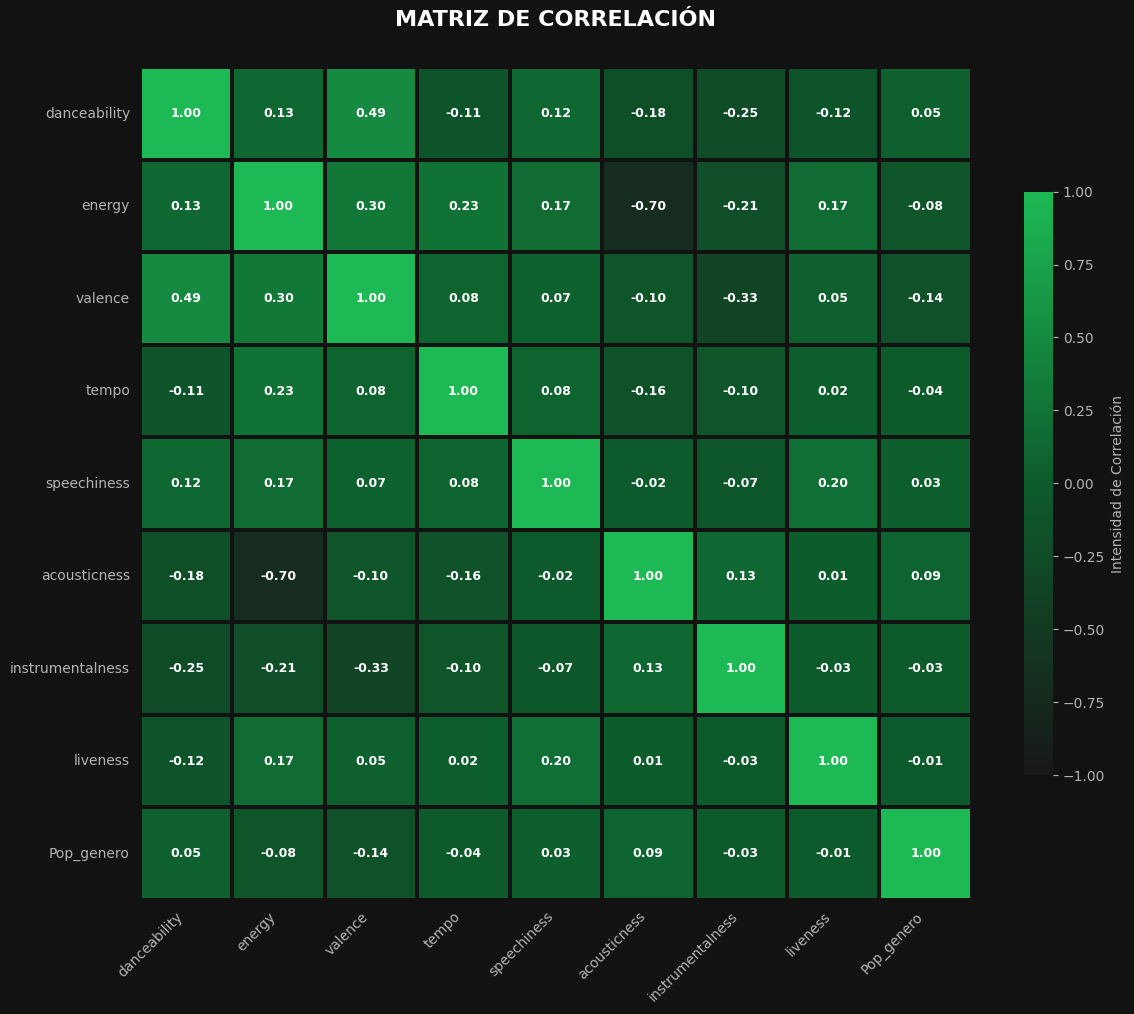

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# 1. PREPARACIÓN DE LOS DATOS (Usando la base 'data')
num_cols = data.select_dtypes(include=['number'])
corr_matrix = num_cols.corr()

# 2. CONFIGURACIÓN ESTILÍSTICA (Tema Spotify Dark)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Poppins', 'Inter', 'Montserrat', 'DejaVu Sans', 'Arial']

COLOR_BG = '#121212'
COLOR_TEXT_MAIN = '#FFFFFF'
COLOR_TEXT_SEC = '#B3B3B3'

plt.rcParams['figure.facecolor'] = COLOR_BG
plt.rcParams['text.color'] = COLOR_TEXT_MAIN

# Gradiente de verdes Spotify
colores_gradiente = ["#181818", "#0D5C2C", "#1DB954"]
cmap_verdes_spotify = LinearSegmentedColormap.from_list("verdes_spotify", colores_gradiente)

# 3. DIBUJAR EL MAPA DE CALOR COMPLETO
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix, 
    cmap=cmap_verdes_spotify, 
    vmax=1.0, vmin=-1.0, 
    annot=True, 
    fmt=".2f", 
    square=True, 
    linewidths=1.5, 
    linecolor=COLOR_BG,        
    cbar_kws={"shrink": 0.7, "label": "Intensidad de Correlación"},
    annot_kws={"size": 9, "weight": "bold"}
)

plt.title("MATRIZ DE CORRELACIÓN", fontsize=16, fontweight='bold', pad=30, color=COLOR_TEXT_MAIN)
plt.xticks(rotation=45, ha='right', fontsize=10, color=COLOR_TEXT_SEC)
plt.yticks(rotation=0, fontsize=10, color=COLOR_TEXT_SEC)

plt.tight_layout()
plt.show()



# Evaluación de Supuestos

## Normalidad

### Prueba de Normalidad Univaraidad

In [44]:
import pandas as pd
import numpy as np
from scipy import stats

# ==============================================================================
# FUNCIÓN CORREGIDA: Calcular p-valor para Anderson-Darling con control de extremos
# ==============================================================================
def calcular_anderson_p_value(A2, N):
    # Corregir el estadístico por el tamaño de muestra N
    A_ajustado = A2 * (1.0 + 0.75 / N + 2.25 / (N ** 2))
    
    # Control de seguridad: Si la desviación es gigantesca, el p-valor es 0.0
    # Esto evita que el término cuadrático positivo (+0.0186 * A^2) explote
    if A_ajustado > 100.0:
        return 0.0
    
    # Calcular p-valor según la fórmula de Stephens (1974)
    if A_ajustado >= 0.600:
        p = np.exp(1.2937 - 5.709 * A_ajustado + 0.0186 * (A_ajustado ** 2))
    elif A_ajustado >= 0.340:
        p = np.exp(0.9177 - 4.279 * A_ajustado - 1.38 * (A_ajustado ** 2))
    elif A_ajustado > 0.200:
        p = 1.0 - np.exp(-8.318 + 42.796 * A_ajustado - 59.938 * (A_ajustado ** 2))
    else:
        p = 1.0 - np.exp(-13.436 + 101.14 * A_ajustado - 223.73 * (A_ajustado ** 2))
        
    return np.clip(p, 0.0, 1.0)

# ==============================================================================
# EJECUCIÓN DEL TEST
# ==============================================================================
resultados_anderson = []
INDICE_5_PORCIENTO = 2
N = len(data)  # N = 5700 datos

for col in data.columns:
    res = stats.anderson(data[col], dist='norm')
    
    estadistico = res.statistic
    valor_critico_5pct = res.critical_values[INDICE_5_PORCIENTO]
    
    # Calcular p-valor exacto
    p_valor = calcular_anderson_p_value(estadistico, N)
    
    # Regla de decisión: p-valor > 0.05 es normal
    es_normal = p_valor > 0.05
    
    resultados_anderson.append({
        'Variable': col,
        'Estadístico (A²)': round(estadistico, 4),
        'Valor Crítico (5%)': round(valor_critico_5pct, 4),
        'p-valor': f"{p_valor:.4e}" if p_valor < 0.0001 else f"{round(p_valor, 5)}",
        '¿Es Normal (al 5%)?': 'Sí' if es_normal else 'No'
    })

# Crear DataFrame y mostrar
df_anderson_completo = pd.DataFrame(resultados_anderson)

print("🔬 --- PRUEBA DE NORMALIDAD DE ANDERSON-DARLING CORREGIDA (N = 5700) ---")
display(df_anderson_completo)


🔬 --- PRUEBA DE NORMALIDAD DE ANDERSON-DARLING CORREGIDA (N = 5700) ---


,Variable,Estadístico (A²),Valor Crítico (5%),p-valor,¿Es Normal (al 5%)?
0,danceability,20.7201,0.786,4.4765e-48,No
1,energy,70.8811,0.786,2.4658e-135,No
2,valence,30.8537,0.786,5.5620e-69,No
3,tempo,25.6349,0.786,2.0156e-58,No
4,speechiness,707.2234,0.786,0.0000e+00,No
5,acousticness,361.2905,0.786,0.0000e+00,No
6,instrumentalness,1433.8374,0.786,0.0000e+00,No
7,liveness,441.2098,0.786,0.0000e+00,No
8,Pop_genero,37.1883,0.786,3.3110e-81,No


### Grafica de Distribución

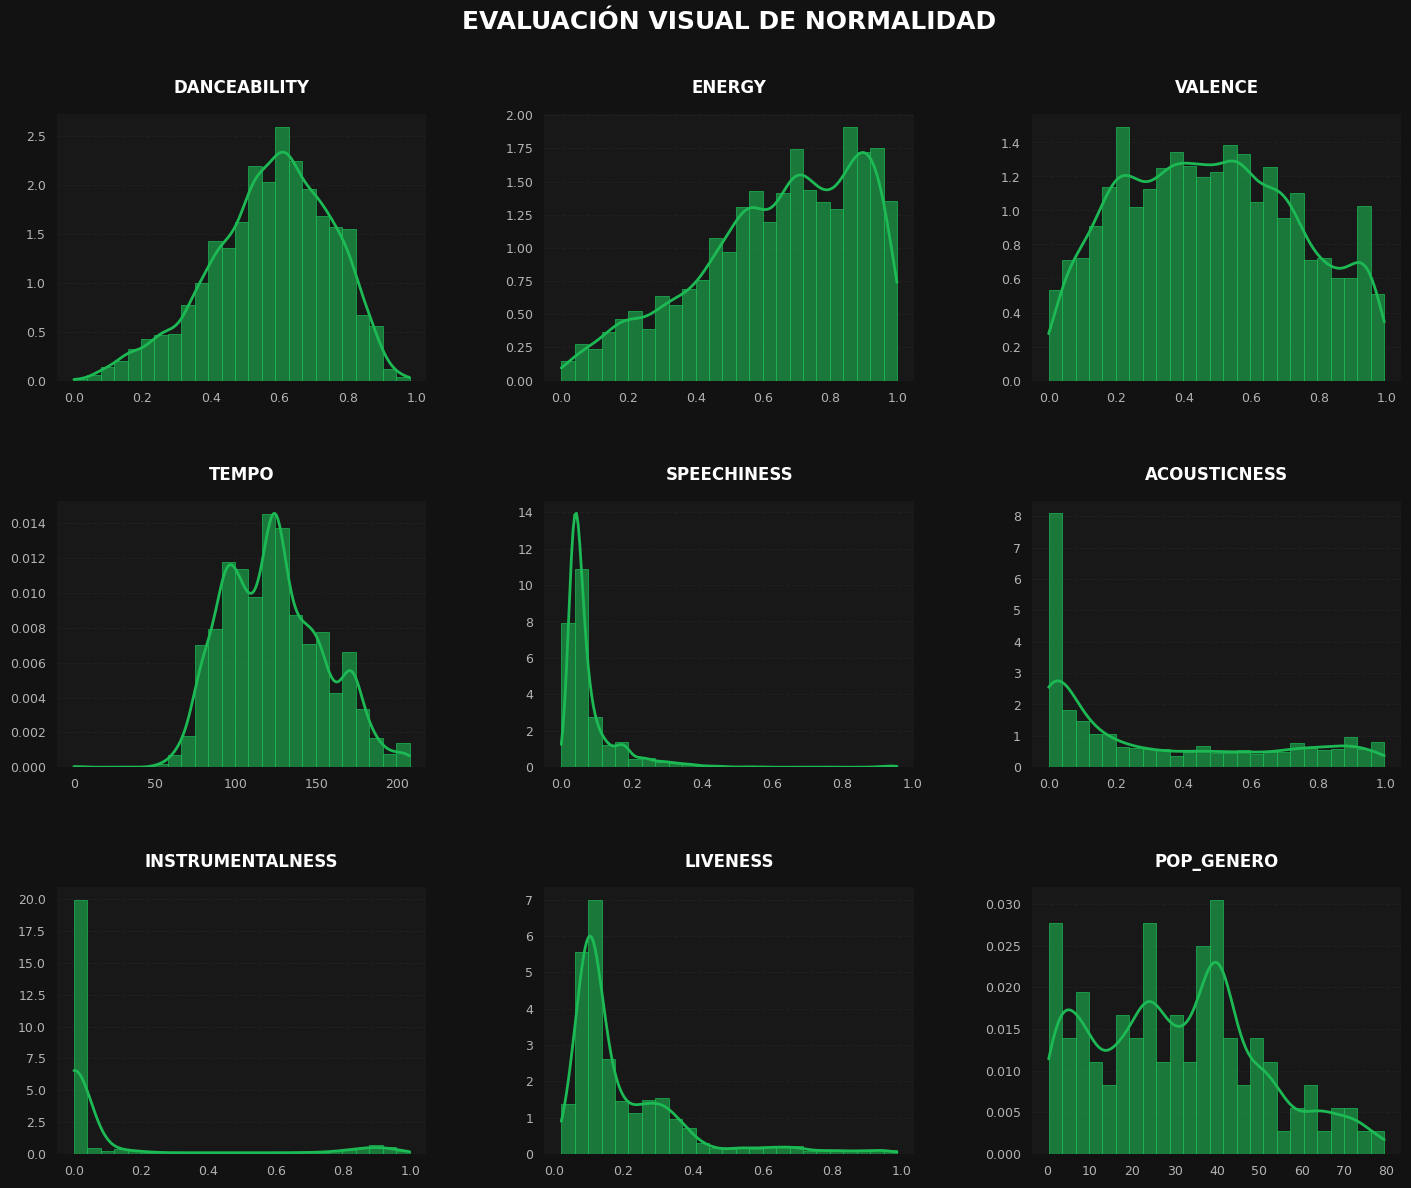

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# CONFIGURACIÓN DEL TEMA OSCURO (Estilo Spotify Minimalista)
# ==============================================================================
# Intentamos aplicar la fuente Poppins, con alternativas estándar por si no está instalada
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Poppins', 'Inter', 'Montserrat', 'DejaVu Sans', 'Arial']

# Colores del tema
COLOR_BG = '#121212'          # Fondo oscuro general (negro Spotify)
COLOR_CARD = '#181818'        # Fondo de cada gráfica (tarjetas)
COLOR_TEXT_MAIN = '#FFFFFF'   # Texto principal blanco
COLOR_TEXT_SEC = '#B3B3B3'    # Texto secundario gris
COLOR_GREEN_SPOTIFY = '#1DB954' # Verde de Spotify para los histogramas
COLOR_GRID = '#282828'        # Líneas de cuadrícula muy tenues

# Aplicar colores a la configuración global de Matplotlib
plt.rcParams['figure.facecolor'] = COLOR_BG
plt.rcParams['axes.facecolor'] = COLOR_CARD
plt.rcParams['text.color'] = COLOR_TEXT_MAIN
plt.rcParams['axes.labelcolor'] = COLOR_TEXT_SEC
plt.rcParams['xtick.color'] = COLOR_TEXT_SEC
plt.rcParams['ytick.color'] = COLOR_TEXT_SEC
plt.rcParams['axes.edgecolor'] = COLOR_GRID
plt.rcParams['grid.color'] = COLOR_GRID

# ==============================================================================
# DIBUJAR LOS GRÁFICOS (Mucho espacio vacío y minimalismo)
# ==============================================================================
# Creamos la cuadrícula con suficiente espacio
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
fig.suptitle("EVALUACIÓN VISUAL DE NORMALIDAD", 
             fontsize=18, fontweight='bold', color=COLOR_TEXT_MAIN, y=0.96)

# Iteramos sobre las 9 variables numéricas
for i, col in enumerate(data.columns):
    row, ax_col = divmod(i, 3)
    ax = axes[row, ax_col]
    
    # Graficamos el Histograma (VERDE SPOTIFY) y la curva KDE (BLANCO)
    sns.histplot(
        data[col], 
        kde=True, 
        ax=ax,
        stat="density", 
        bins=25, 
        color=COLOR_GREEN_SPOTIFY,   # Histogramas del VERDE DE SPOTIFY
        alpha=0.6,                   # Transparencia ideal para las barras
        edgecolor=COLOR_GREEN_SPOTIFY, # Borde de las barras verde
        linewidth=0.5,
        line_kws={"color": COLOR_TEXT_MAIN, "linewidth": 2} # Curva KDE destacada en BLANCO
    )
    
    # Diseño minimalista: Eliminar los bordes (Spines) de la gráfica
    for spine in ax.spines.values():
        spine.set_visible(False)
        
    # Añadir líneas de cuadrícula sutiles solo para el eje Y
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)
    ax.grid(False, axis='x')
    
    # Configurar títulos y etiquetas limpios
    ax.set_title(col.upper(), fontsize=12, fontweight='bold', color=COLOR_TEXT_MAIN, pad=15)
    ax.set_xlabel("")
    ax.set_ylabel("")
    
    # Espaciado y tamaño en los números de los ejes
    ax.tick_params(axis='both', which='both', length=0, pad=8, labelsize=9)

# Espacio vacío abundante entre tarjetas para diseño limpio y aireado
plt.subplots_adjust(left=0.08, right=0.92, bottom=0.08, top=0.88, wspace=0.32, hspace=0.45)
plt.show()


### Evaluación de normalidad Multivariada

In [50]:
import numpy as np
from scipy import stats
def mardia_report(df_data):
    X = df_data.values
    n, p = X.shape
    
    # 1. Centrar los datos respecto a la media
    X_centro = X - np.mean(X, axis=0)
    
    # 2. Calcular la matriz de covarianza muestral e inversa
    S = np.cov(X_centro, rowvar=False, ddof=0)
    S_inv = np.linalg.inv(S)
    
    # 3. Calcular la matriz de distancias cruzadas de Mahalanobis (D)
    D = np.dot(np.dot(X_centro, S_inv), X_centro.T)
    
    # ----------------------------------------------------
    # ASIMETRÍA MULTIVARIADA
    # ----------------------------------------------------
    b1p = np.sum(D ** 3) / (n ** 2)
    asimetria_est = (n / 6.0) * b1p
    asimetria_gl = int(p * (p + 1) * (p + 2) / 6.0)
    asimetria_p = 1.0 - stats.chi2.cdf(asimetria_est, asimetria_gl)
    normal_asimetria = 'Sí ✅' if asimetria_p > 0.05 else 'No ❌'
    
    # ----------------------------------------------------
    # CURTOSIS MULTIVARIADA
    # ----------------------------------------------------
    b2p = np.sum(np.diag(D) ** 2) / n
    esperada_kurt = float(p * (p + 2))
    curtosis_est = (b2p - esperada_kurt) / np.sqrt(8.0 * p * (p + 2) / n)
    curtosis_p = 2.0 * (1.0 - stats.norm.cdf(np.abs(curtosis_est)))
    normal_curtosis = 'Sí ✅' if curtosis_p > 0.05 else 'No ❌'
    
    # ----------------------------------------------------
    # IMPRESIÓN DEL REPORTE CON FORMATO SOLICITADO
    # ----------------------------------------------------
    print("📊 TEST DE MARDIA")
    print("───────────────────────────────────────────────────────")
    print(f"  Asimetría (b₁,p):      {b1p:.4f}")
    print(f"    Estadístico χ²:      {asimetria_est:.4f}")
    print(f"    gl:                  {asimetria_gl}")
    print(f"    P-valor:             {asimetria_p:.6f}")
    print(f"    Normal:              {normal_asimetria}")
    print()
    print(f"  Curtosis (b₂,p):       {b2p:.4f}")
    print(f"    Esperada:            {esperada_kurt:.4f}")
    print(f"    Estadístico Z:       {curtosis_est:.4f}")
    print(f"    P-valor:             {curtosis_p:.6f}")
    print(f"    Normal:              {normal_curtosis}")
# Ejecutar el reporte con tus 9 variables de 'data'
mardia_report(data)


📊 TEST DE MARDIA
───────────────────────────────────────────────────────
  Asimetría (b₁,p):      39.4319
    Estadístico χ²:      37460.2859
    gl:                  165
    P-valor:             0.000000
    Normal:              No ❌

  Curtosis (b₂,p):       145.3112
    Esperada:            99.0000
    Estadístico Z:       124.2399
    P-valor:             0.000000
    Normal:              No ❌


### Q-Q plot multivaraido

<>:88: SyntaxWarning: invalid escape sequence '\c'
<>:88: SyntaxWarning: invalid escape sequence '\c'
C:\Users\josue\AppData\Local\Temp\ipykernel_19640\1539978468.py:88: SyntaxWarning: invalid escape sequence '\c'
  plt.xlabel("Cuantiles Teóricos de Chi-Cuadrado $\chi^2(df=9)$", fontsize=11, labelpad=15, color=COLOR_TEXT_SEC)


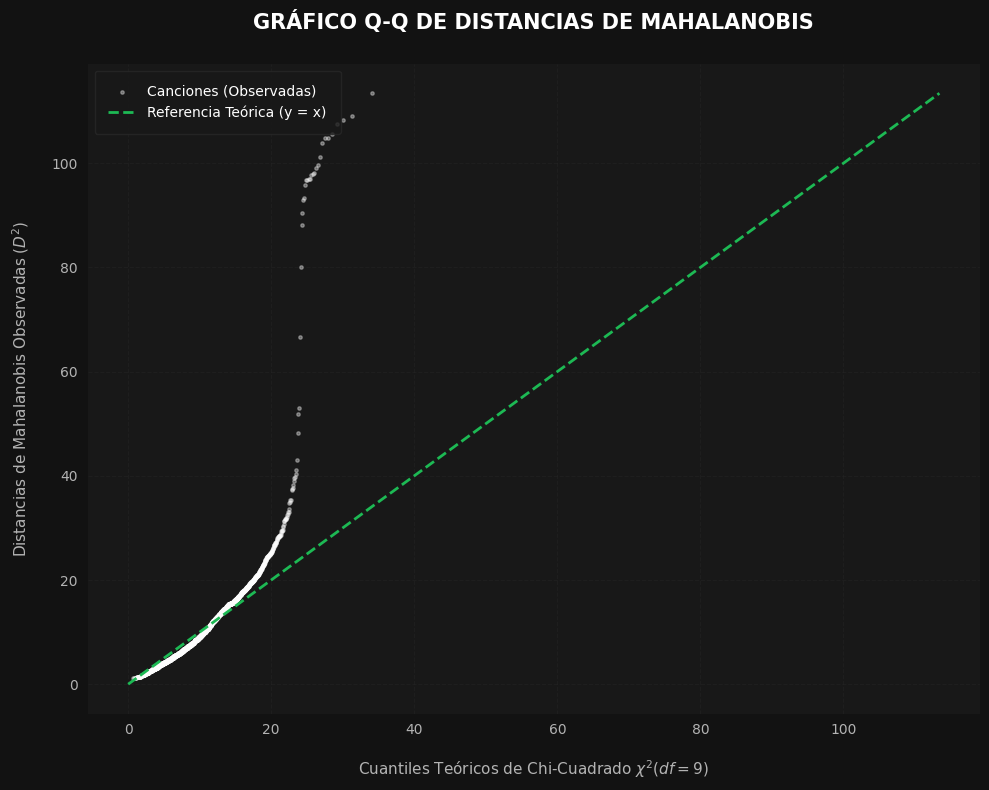

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ==============================================================================
# 1. CÁLCULO DE LAS DISTANCIAS DE MAHALANOBIS (Al cuadrado)
# ==============================================================================
X = data.values
n, p = X.shape

# Centrar los datos respecto a la media conjunta
X_centro = X - np.mean(X, axis=0)

# Calcular matriz de covarianza e inversa
S = np.cov(X_centro, rowvar=False, ddof=0)
S_inv = np.linalg.inv(S)

# Calcular las distancias de Mahalanobis al cuadrado de manera eficiente en memoria
d2 = np.sum(np.dot(X_centro, S_inv) * X_centro, axis=1)
d2_sorted = np.sort(d2)

# ==============================================================================
# 2. CALCULAR LOS CUANTILES TEÓRICOS DE CHI-CUADRADO (gl = p = 9 variables)
# ==============================================================================
probs = (np.arange(1, n + 1) - 0.5) / n
chi2_quantiles = stats.chi2.ppf(probs, df=p)

# ==============================================================================
# 3. GRAFICACIÓN CON ESTILO OSCURO (Spotify Dark Mode)
# ==============================================================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Poppins', 'Inter', 'Montserrat', 'DejaVu Sans', 'Arial']

# Definición de colores
COLOR_BG = '#121212'          # Fondo oscuro general (negro Spotify)
COLOR_CARD = '#181818'        # Tarjeta de fondo de la gráfica
COLOR_TEXT_MAIN = '#FFFFFF'   # Texto principal blanco
COLOR_TEXT_SEC = '#B3B3B3'    # Texto secundario gris
COLOR_GREEN = '#1DB954'       # Verde de Spotify para destacar
COLOR_GRID = '#282828'        # Líneas de cuadrícula sutiles

# Aplicar colores a matplotlib
plt.rcParams['figure.facecolor'] = COLOR_BG
plt.rcParams['axes.facecolor'] = COLOR_CARD
plt.rcParams['text.color'] = COLOR_TEXT_MAIN
plt.rcParams['axes.labelcolor'] = COLOR_TEXT_SEC
plt.rcParams['xtick.color'] = COLOR_TEXT_SEC
plt.rcParams['ytick.color'] = COLOR_TEXT_SEC
plt.rcParams['axes.edgecolor'] = COLOR_GRID
plt.rcParams['grid.color'] = COLOR_GRID

# Crear figura
plt.figure(figsize=(10, 8))
ax = plt.gca()

# Graficar las observaciones como puntos blancos pequeños y semi-transparentes
plt.scatter(
    chi2_quantiles, 
    d2_sorted, 
    color=COLOR_TEXT_MAIN, 
    alpha=0.35, 
    s=6, 
    label='Canciones (Observadas)',
    zorder=2
)

# Graficar la diagonal teórica de identidad (Verde Spotify destacado)
limites_ejes = [0, max(max(chi2_quantiles), max(d2_sorted))]
plt.plot(
    limites_ejes, 
    limites_ejes, 
    color=COLOR_GREEN, 
    linewidth=2, 
    linestyle='--', 
    label='Referencia Teórica (y = x)',
    zorder=3
)

# Estilo minimalista puro
for spine in ax.spines.values():
    spine.set_visible(False)  # Quitar bordes para limpieza visual

ax.grid(True, linestyle='--', alpha=0.4, zorder=1) # Cuadrícula sutil

# Títulos y etiquetas grandes y limpios
plt.title("GRÁFICO Q-Q DE DISTANCIAS DE MAHALANOBIS", fontsize=15, fontweight='bold', pad=25, color=COLOR_TEXT_MAIN)
plt.xlabel("Cuantiles Teóricos de Chi-Cuadrado $\chi^2(df=9)$", fontsize=11, labelpad=15, color=COLOR_TEXT_SEC)
plt.ylabel("Distancias de Mahalanobis Observadas ($D^2$)", fontsize=11, labelpad=15, color=COLOR_TEXT_SEC)

# Leyenda premium flotante
plt.legend(
    facecolor=COLOR_CARD, 
    edgecolor=COLOR_GRID, 
    loc='upper left', 
    fontsize=10, 
    frameon=True,
    borderpad=1.0
)

plt.tight_layout()
plt.show()


## Evaluación de linealidad

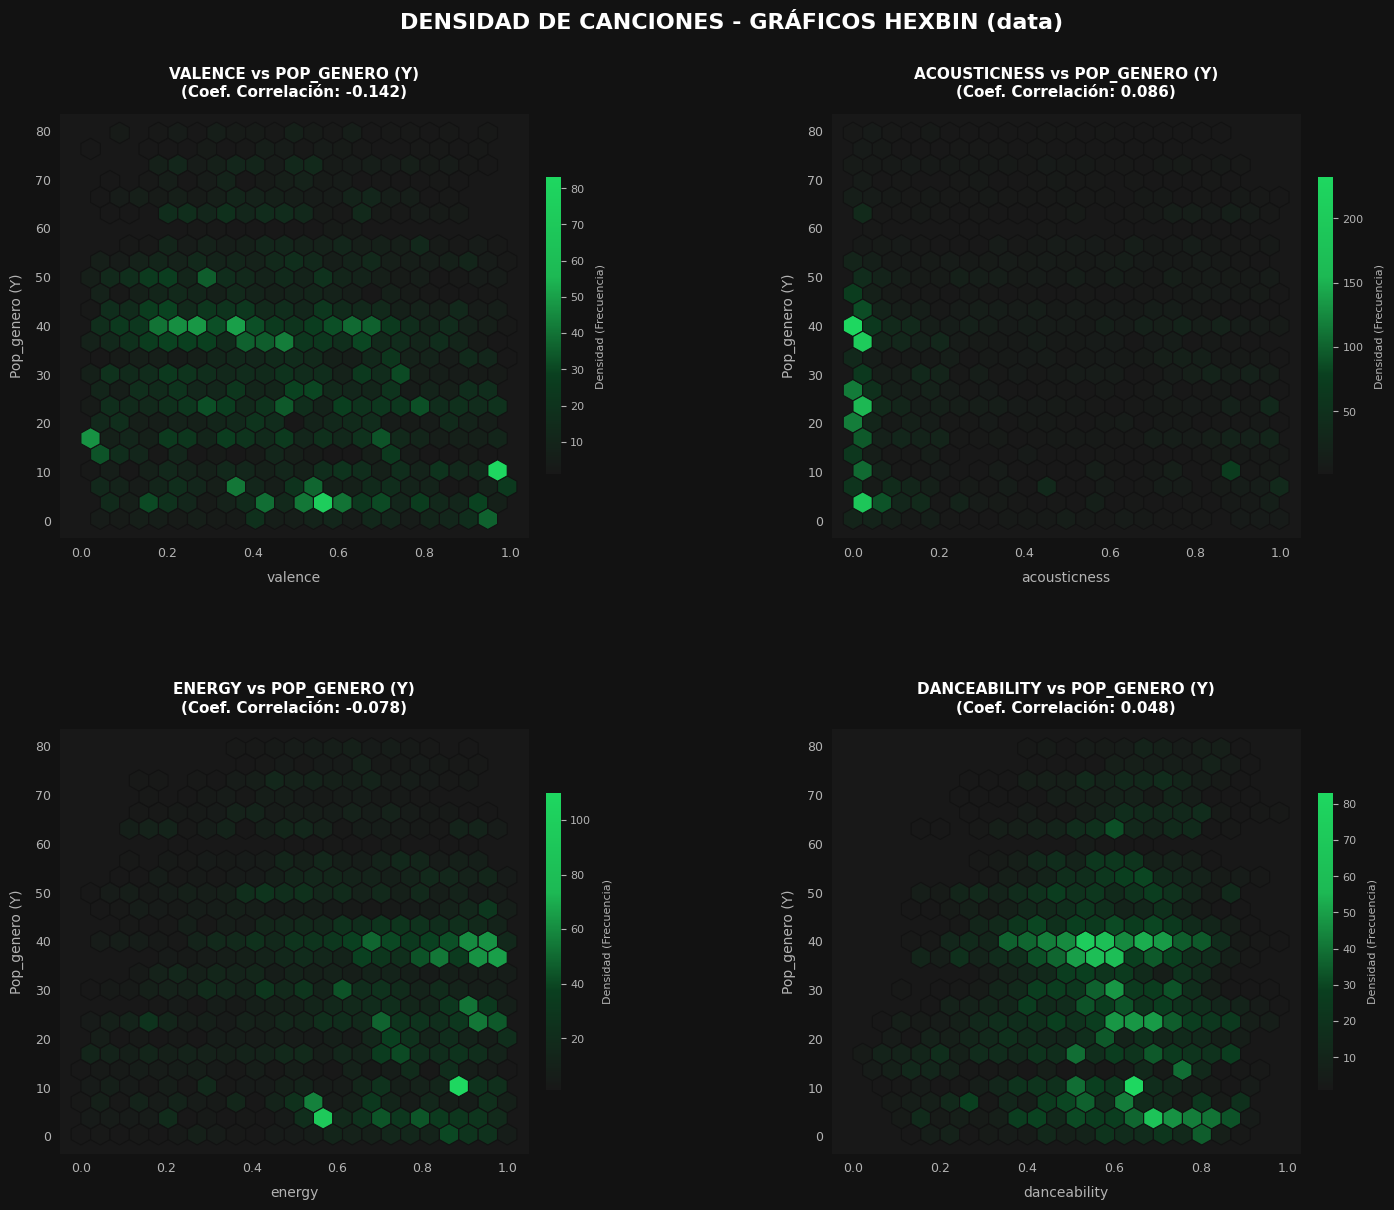

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
# ==============================================================================
# 1. DETECCIÓN AUTOMÁTICA DEL TOP 4 DE VARIABLES MÁS INFLUYENTES EN 'Pop_genero'
# ==============================================================================
correlaciones_con_y = data.corr()['Pop_genero'].drop('Pop_genero')
top_4_independientes = correlaciones_con_y.abs().sort_values(ascending=False).head(4).index.tolist()
# ==============================================================================
# 2. CONFIGURACIÓN ESTILÍSTICA (Tema Spotify Dark con Gradiente Verde de Densidad)
# ==============================================================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Poppins', 'Inter', 'Montserrat', 'DejaVu Sans', 'Arial']
COLOR_BG = '#121212'          # Fondo de la imagen general
COLOR_CARD = '#181818'        # Fondo de las tarjetas de los subplots
COLOR_TEXT_MAIN = '#FFFFFF'   # Blanco texto
COLOR_TEXT_SEC = '#B3B3B3'    # Gris texto secundario
COLOR_GREEN = '#1DB954'       # Verde de Spotify para destacar densidad
# Configuración global
plt.rcParams['figure.facecolor'] = COLOR_BG
plt.rcParams['text.color'] = COLOR_TEXT_MAIN
plt.rcParams['axes.labelcolor'] = COLOR_TEXT_SEC
plt.rcParams['xtick.color'] = COLOR_TEXT_SEC
plt.rcParams['ytick.color'] = COLOR_TEXT_SEC
# GRADIENTE DE DENSIDAD PERSONALIZADO:
# Va desde el fondo oscuro de las tarjetas, sube por verde oscuro, verde Spotify hasta un verde neón brillante
cmap_hex_spotify = LinearSegmentedColormap.from_list(
    "hex_spotify", 
    [COLOR_CARD, "#0A3F1F", COLOR_GREEN, "#1ED760"]
)
# ==============================================================================
# 3. DIBUJAR EL DASHBOARD 2x2 DE HEXBINS GLOWING
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 13))
fig.suptitle("DENSIDAD DE CANCIONES - GRÁFICOS HEXBIN (data)", 
             fontsize=16, fontweight='bold', color=COLOR_TEXT_MAIN, y=0.96)
# Iterar sobre el Top 4 de variables
for i, var_x in enumerate(top_4_independientes):
    row, col = divmod(i, 2)
    ax = axes[row, col]
    
    # Coeficiente de correlación real con signo
    coef_corr = correlaciones_con_y[var_x]
    
    # Dibujar el gráfico Hexbin
    hb = ax.hexbin(
        data[var_x], 
        data['Pop_genero'], 
        gridsize=22,         # Tamaño y resolución de los hexágonos
        cmap=cmap_hex_spotify, 
        mincnt=1,            # Solo pintar hexágonos con al menos 1 observación
        edgecolors=COLOR_BG, # Líneas de división con el fondo general para efecto rejilla flotante
        linewidths=0.8
    )
    
    # Estilo minimalista puro (Sin bordes en las gráficas)
    for spine in ax.spines.values():
        spine.set_visible(False)
        
    ax.grid(False) # Sin rejilla de fondo para no ensuciar la distribución hexagonal
    
    # Configurar títulos e identificaciones de los ejes en Poppins
    ax.set_title(f"{var_x.upper()} vs POP_GENERO (Y)\n(Coef. Correlación: {coef_corr:.3f})", 
                 fontsize=11, fontweight='bold', color=COLOR_TEXT_MAIN, pad=12)
    ax.set_xlabel(var_x, fontsize=10, labelpad=8)
    ax.set_ylabel("Pop_genero (Y)", fontsize=10, labelpad=8)
    
    # Quitar marcas físicas de ejes pero conservar los números
    ax.tick_params(axis='both', which='both', length=0, pad=6, labelsize=9)
    
    # Añadir barra de color (Colorbar) minimalista y sutil a la derecha de cada tarjeta
    cb = fig.colorbar(hb, ax=ax, shrink=0.7, pad=0.03)
    cb.set_label('Densidad (Frecuencia)', color=COLOR_TEXT_SEC, fontsize=8, labelpad=8)
    cb.ax.tick_params(labelsize=8, colors=COLOR_TEXT_SEC)
    cb.outline.set_visible(False) # Ocultar bordes de la barra de color
# Configurar abundante espacio vacío entre tarjetas para diseño limpio
plt.subplots_adjust(left=0.08, right=0.92, bottom=0.08, top=0.88, wspace=0.35, hspace=0.45)
plt.show()

## Evaluación de Multicolinealidad

In [58]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# ==============================================================================
# 1. PREPARACIÓN DE LAS VARIABLES INDEPENDIENTES (X)
# ==============================================================================
# Excluimos la variable dependiente Y (Pop_genero) para evaluar solo las X
X = data.drop(columns=['Pop_genero'])

# Agregamos una columna de constantes (intercepto) requerida por statsmodels
# Esto garantiza que el cálculo matemático del VIF sea 100% correcto
X_con_constante = add_constant(X)

# ==============================================================================
# 2. CÁLCULO DEL FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)
# ==============================================================================
resultados_vif = []

# Iteramos sobre las variables independientes (nos saltamos la columna de constante en el índice 0)
for i in range(1, X_con_constante.shape[1]):
    nombre_columna = X_con_constante.columns[i]
    valor_vif = variance_inflation_factor(X_con_constante.values, i)
    
    # Determinar nivel de riesgo según los estándares estadísticos
    if valor_vif < 5.0:
        riesgo = 'Bajo (Seguro)'
    elif valor_vif < 10.0:
        riesgo = 'Moderado (Tolerable) ⚠️'
    else:
        riesgo = 'Alto (Multicolinealidad Crítica) ❌'
        
    resultados_vif.append({
        'Variable Independiente (X)': nombre_columna,
        'VIF': round(valor_vif, 4),
        'Evaluación': riesgo
    })

# ==============================================================================
# 3. MOSTRAR RESULTADOS
# ==============================================================================
df_vif = pd.DataFrame(resultados_vif)
# Ordenamos de mayor a menor VIF para identificar rápidamente variables críticas
df_vif = df_vif.sort_values(by='VIF', ascending=False).reset_index(drop=True)

print("🔬 --- EVALUACIÓN DE MULTICOLINEALIDAD (FACTOR VIF) ---")
display(df_vif)


🔬 --- EVALUACIÓN DE MULTICOLINEALIDAD (FACTOR VIF) ---


,Variable Independiente (X),VIF,Evaluación
0,energy,2.4965,Bajo (Seguro)
1,acousticness,2.2115,Bajo (Seguro)
2,valence,1.6082,Bajo (Seguro)
3,danceability,1.5323,Bajo (Seguro)
4,instrumentalness,1.1620,Bajo (Seguro)
5,liveness,1.1192,Bajo (Seguro)
6,speechiness,1.1154,Bajo (Seguro)
7,tempo,1.1057,Bajo (Seguro)


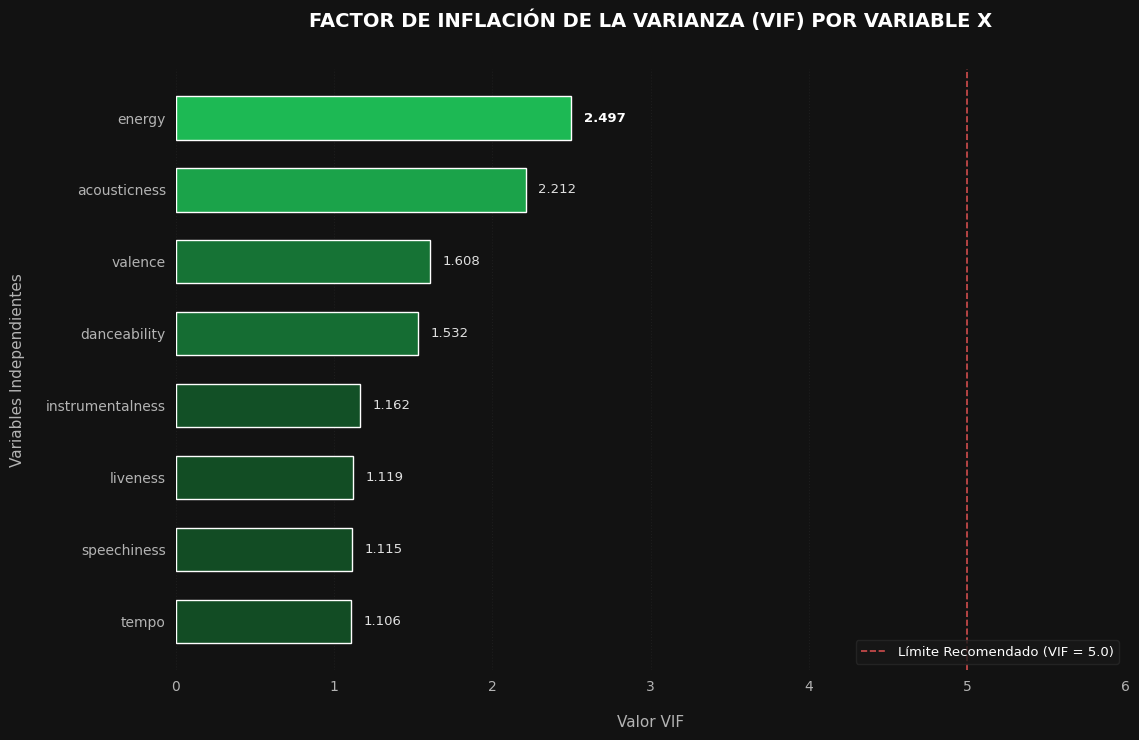

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# ==============================================================================
# 1. CÁLCULO DEL VIF DE LAS VARIABLES INDEPENDIENTES (X)
# ==============================================================================
# Excluimos Y (Pop_genero) y agregamos constante
X = data.drop(columns=['Pop_genero'])
X_con_constante = add_constant(X)
resultados_vif = []

for i in range(1, X_con_constante.shape[1]):
    nombre_columna = X_con_constante.columns[i]
    valor_vif = variance_inflation_factor(X_con_constante.values, i)
    resultados_vif.append({
        'Variable': nombre_columna,
        'VIF': valor_vif
    })

# Ordenar de menor a de mayor VIF (para que la mayor quede arriba en barra horizontal)
df_vif = pd.DataFrame(resultados_vif).sort_values(by='VIF', ascending=True).reset_index(drop=True)

# ==============================================================================
# 2. CONFIGURACIÓN ESTILÍSTICA (Tema Spotify Dark Premium)
# ==============================================================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Poppins', 'Inter', 'Montserrat', 'DejaVu Sans', 'Arial']

# Paleta de Colores Oficiales de Spotify
COLOR_BG = '#121212'            # Negro base de Spotify
COLOR_TEXT_MAIN = '#FFFFFF'      # Blanco puro para textos principales
COLOR_TEXT_SEC = '#B3B3B3'       # Gris claro para textos secundarios y ejes
COLOR_GRID = '#222222'           # Rejilla extremadamente sutil
COLOR_LIMIT = '#FF5B5B'          # Rojo coral elegante para la línea límite

# Tonalidades Verde Spotify (De verde oscuro elegante a verde brillante oficial)
VERDE_OSCURO = '#124C24'         # Inicio del gradiente (Verde bosque visible)
VERDE_BRILLANTE = '#1DB954'      # Fin del gradiente (Verde oficial brillante)

# Creación del gradiente de verdes lineal
cmap_spotify = mcolors.LinearSegmentedColormap.from_list('spotify_green_grad', [VERDE_OSCURO, VERDE_BRILLANTE])
norm = plt.Normalize(vmin=df_vif['VIF'].min(), vmax=df_vif['VIF'].max())
colores_barras = [cmap_spotify(norm(val)) for val in df_vif['VIF']]

# Configuración global de Matplotlib
plt.rcParams['figure.facecolor'] = COLOR_BG
plt.rcParams['axes.facecolor'] = COLOR_BG
plt.rcParams['text.color'] = COLOR_TEXT_MAIN
plt.rcParams['axes.labelcolor'] = COLOR_TEXT_SEC
plt.rcParams['xtick.color'] = COLOR_TEXT_SEC
plt.rcParams['ytick.color'] = COLOR_TEXT_SEC

# ==============================================================================
# 3. DIBUJAR EL GRÁFICO DE BARRAS HORIZONTALES
# ==============================================================================
plt.figure(figsize=(11.5, 7.5))
ax = plt.gca()

# Dibujar las barras con el gradiente de verdes
bars = ax.barh(
    df_vif['Variable'], 
    df_vif['VIF'], 
    color=colores_barras,
    edgecolor=None, 
    height=0.6,
    zorder=2
)

# Dibujar la línea de control científico en VIF = 5.0
plt.axvline(
    x=5.0, 
    color=COLOR_LIMIT, 
    linestyle='--', 
    linewidth=1.2, 
    alpha=0.8, 
    label='Límite Recomendado (VIF = 5.0)',
    zorder=1
)

# Agregar las etiquetas de texto con el valor exacto de VIF al lado de cada barra
vif_maximo = df_vif['VIF'].max()
for bar in bars:
    ancho = bar.get_width()
    # Resaltar en blanco negrita la barra de mayor VIF, las demás en blanco estándar legible
    es_max = (ancho == vif_maximo)
    txt_color = COLOR_TEXT_MAIN if es_max else '#E0E0E0'
    peso_fuente = 'bold' if es_max else 'normal'
    
    ax.text(
        ancho + 0.08, 
        bar.get_y() + bar.get_height()/2, 
        f'{ancho:.3f}', 
        va='center', 
        ha='left', 
        fontsize=9.5, 
        fontweight=peso_fuente,
        color=txt_color
    )

# Estilo minimalista puro (sin espinas/bordes)
for spine in ax.spines.values():
    spine.set_visible(False)

# Rejilla extremadamente sutil solo en el eje X
ax.grid(True, axis='x', color=COLOR_GRID, linestyle=':', alpha=0.7, zorder=0)
ax.grid(False, axis='y')

# Título y etiquetas con tipografía limpia y amplio espacio libre
plt.title("FACTOR DE INFLACIÓN DE LA VARIANZA (VIF) POR VARIABLE X", 
          fontsize=14, fontweight='bold', pad=30, color=COLOR_TEXT_MAIN)
plt.xlabel("Valor VIF", fontsize=11, labelpad=15, color=COLOR_TEXT_SEC)
plt.ylabel("Variables Independientes", fontsize=11, labelpad=15, color=COLOR_TEXT_SEC)

# Ajustar límites del eje X dando margen a los números
plt.xlim(0, max(max(df_vif['VIF']) + 1.0, 6.0))

# Leyenda flotante elegante integrada
plt.legend(
    facecolor='#181818', 
    edgecolor='#282828', 
    loc='lower right', 
    fontsize=9.5, 
    labelcolor=COLOR_TEXT_MAIN
)

plt.tight_layout()
plt.show()


## Detección de Outliers

### Outliers Univariados 

In [77]:
import pandas as pd
import numpy as np
from IPython.display import display
# ==============================================================================
# 1. CÁLCULO DE MÁSCARA Y DETECCIÓN DE OUTLIERS (IQR)
# ==============================================================================
res_outliers = []
columnas_analisis = list(data.columns)
# DataFrame para rastrear outliers a nivel de celdas (fila x columna)
mascara_outliers = pd.DataFrame(False, index=data.index, columns=columnas_analisis)
for col in columnas_analisis:
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    
    # Rellenar la máscara booleana
    mascara_outliers[col] = (data[col] < limite_inferior) | (data[col] > limite_superior)
    
    total_outliers = mascara_outliers[col].sum()
    porcentaje = (total_outliers / len(data)) * 100
    tiene_outliers = "Sí" if total_outliers > 0 else "No"
    
    res_outliers.append({
        'Variable': col,
        'Q1 (25%)': q1,
        'Mediana (50%)': data[col].median(),
        'Q3 (75%)': q3,
        'IQR': iqr,
        'Límite Inferior': limite_inferior,
        'Límite Superior': limite_superior,
        'N° Outliers': int(total_outliers),
        '% Outliers': porcentaje,
        '¿Tiene Outliers?': tiene_outliers
    })
# DataFrame 1: Reporte por Variable
df_variables = pd.DataFrame(res_outliers)
# ==============================================================================
# 2. CÁLCULO DE OUTLIERS TOTALES A NIVEL GLOBAL DE LA BASE
# ==============================================================================
total_registros = len(data)
outliers_por_fila = mascara_outliers.sum(axis=1)
# Filas atípicas (al menos una columna fuera de rango)
filas_con_outliers = (outliers_por_fila > 0).sum()
filas_sin_outliers = (outliers_por_fila == 0).sum()
pct_filas_con = (filas_con_outliers / total_registros) * 100
pct_filas_sin = (filas_sin_outliers / total_registros) * 100
suma_total_celdas_atipicas = mascara_outliers.sum().sum()
# DataFrame 2: Métricas Consolidadas
metricas_globales = [
    {"Métrica Global de la Base": "Total de Canciones en la Base (N)", "Valor": f"{total_registros:,}", "Interpretación": "Tamaño muestral completo"},
    {"Métrica Global de la Base": "Canciones SIN ningún Outlier", "Valor": f"{filas_sin_outliers:,} ({pct_filas_sin:.2f}%)", "Interpretación": "Registros estables y típicos"},
    {"Métrica Global de la Base": "Canciones con AL MENOS 1 Outlier", "Valor": f"{filas_con_outliers:,} ({pct_filas_con:.2f}%)", "Interpretación": "Registros con comportamiento atípico"},
    {"Métrica Global de la Base": "Suma Total de Celdas Atípicas en la Matriz", "Valor": f"{int(suma_total_celdas_atipicas):,}", "Interpretación": "Puntos de datos extremos acumulados"}
]
df_global = pd.DataFrame(metricas_globales)
# ==============================================================================
# 3. DISEÑO Y ESTILIZACIÓN DE LAS TABLAS (Tema Spotify Dark)
# ==============================================================================
# Estilos CSS comunes para ambas tablas
propiedades_comunes = {
    'background-color': '#181818',
    'color': '#FFFFFF',
    'border': '1px solid #282828',
    'font-family': "'Poppins', 'Inter', sans-serif",
    'text-align': 'center',
    'padding': '12px 15px',
    'font-size': '12.5px'
}
estilos_cabecera = [
    {
        'selector': 'th',
        'props': [
            ('background-color', '#121212'),
            ('color', '#B3B3B3'),
            ('font-weight', 'bold'),
            ('border', '1px solid #282828'),
            ('border-bottom', '3px solid #1DB954'), # Línea distintiva Spotify
            ('padding', '12px 15px'),
            ('font-size', '13px'),
            ('text-transform', 'uppercase')
        ]
    },
    {
        'selector': 'caption',
        'props': [
            ('color', '#FFFFFF'),
            ('font-size', '15px'),
            ('font-weight', 'bold'),
            ('padding', '15px'),
            ('background-color', '#121212'),
            ('text-align', 'center'),
            ('font-family', "'Poppins', sans-serif"),
            ('letter-spacing', '1px'),
            ('border-bottom', '1px solid #282828')
        ]
    },
    {
        'selector': 'tr:hover',
        'props': [
            ('background-color', '#222222'),
            ('transition', 'background-color 0.2s ease')
        ]
    }
]
# Estilizar Tabla 1: Variables
def color_alertas(val):
    if val == "Sí":
        return "color: #1DB954; font-weight: bold;"
    return "color: #B3B3B3; font-style: italic;"
def destacar_outliers(val):
    if isinstance(val, (int, np.integer)) and val > 0:
        return "background-color: #16321F; color: #1DB954; font-weight: bold; border-radius: 4px;"
    return "color: #E0E0E0;"
tabla_variables_estilizada = df_variables.style \
    .set_caption("1. DETECCIÓN DE OUTLIERS POR VARIABLE INDEPENDIENTE") \
    .format({
        'Q1 (25%)': '{:.4f}',
        'Mediana (50%)': '{:.4f}',
        'Q3 (75%)': '{:.4f}',
        'IQR': '{:.4f}',
        'Límite Inferior': '{:.4f}',
        'Límite Superior': '{:.4f}',
        '% Outliers': '{:.2f}%',
        'N° Outliers': '{:d}'
    }) \
    .set_properties(**propiedades_comunes) \
    .set_table_styles(estilos_cabecera)
if hasattr(tabla_variables_estilizada, 'map'):
    tabla_variables_estilizada = tabla_variables_estilizada.map(color_alertas, subset=['¿Tiene Outliers?'])
    tabla_variables_estilizada = tabla_variables_estilizada.map(destacar_outliers, subset=['N° Outliers'])
else:
    tabla_variables_estilizada = tabla_variables_estilizada.applymap(color_alertas, subset=['¿Tiene Outliers?'])
    tabla_variables_estilizada = tabla_variables_estilizada.applymap(destacar_outliers, subset=['N° Outliers'])
# Estilizar Tabla 2: Consolidado Global de la Base
tabla_global_estilizada = df_global.style \
    .set_caption("2. CONSOLIDADO DE VALORES ATÍPICOS EN LA BASE COMPLETA") \
    .set_properties(**propiedades_comunes) \
    .set_table_styles(estilos_cabecera) \
    .set_properties(subset=['Métrica Global de la Base'], **{'text-align': 'left', 'font-weight': 'bold'}) \
    .set_properties(subset=['Interpretación'], **{'text-align': 'left', 'color': '#B3B3B3'}) \
    .set_properties(subset=['Valor'], **{'color': '#1DB954', 'font-weight': 'bold', 'font-size': '13.5px'})
# ==============================================================================
# 4. RENDERIZADO SIMULTÁNEO EN EL NOTEBOOK
# ==============================================================================
display(tabla_variables_estilizada)
print("\n" + "="*90 + "\n") # Separador visual elegante
display(tabla_global_estilizada)

,Variable,Q1 (25%),Mediana (50%),Q3 (75%),IQR,Límite Inferior,Límite Superior,N° Outliers,% Outliers,¿Tiene Outliers?
0,danceability,0.4640,0.5910,0.7030,0.2390,0.1055,1.0615,41,0.72%,Sí
1,energy,0.4850,0.6820,0.8480,0.3630,-0.0595,1.3925,0,0.00%,No
2,valence,0.2698,0.4720,0.6720,0.4022,-0.3336,1.2754,0,0.00%,No
3,tempo,99.9688,122.8720,143.9932,44.0245,33.9320,210.0300,4,0.07%,Sí
4,speechiness,0.0359,0.0494,0.0844,0.0485,-0.0369,0.1572,709,12.44%,Sí
5,acousticness,0.0200,0.1620,0.5920,0.5720,-0.8380,1.4500,0,0.00%,No
6,instrumentalness,0.0000,0.0000,0.0075,0.0075,-0.0112,0.0186,1301,22.82%,Sí
7,liveness,0.0959,0.1270,0.2600,0.1641,-0.1503,0.5062,356,6.25%,Sí
8,Pop_genero,15.8400,30.9200,42.6800,26.8400,-24.4200,82.9400,0,0.00%,No


,Métrica Global de la Base,Valor,Interpretación
0,Total de Canciones en la Base (N),"5,700",Tamaño muestral completo
1,Canciones SIN ningún Outlier,"3,568 (62.60%)",Registros estables y típicos
2,Canciones con AL MENOS 1 Outlier,"2,132 (37.40%)",Registros con comportamiento atípico
3,Suma Total de Celdas Atípicas en la Matriz,"2,411",Puntos de datos extremos acumulados


### BOX-PLOT

C:\Users\josue\AppData\Local\Temp\ipykernel_19640\845862979.py:137: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.02, 1, 0.93], h_pad=4.5, w_pad=2.5)
C:\Users\josue\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


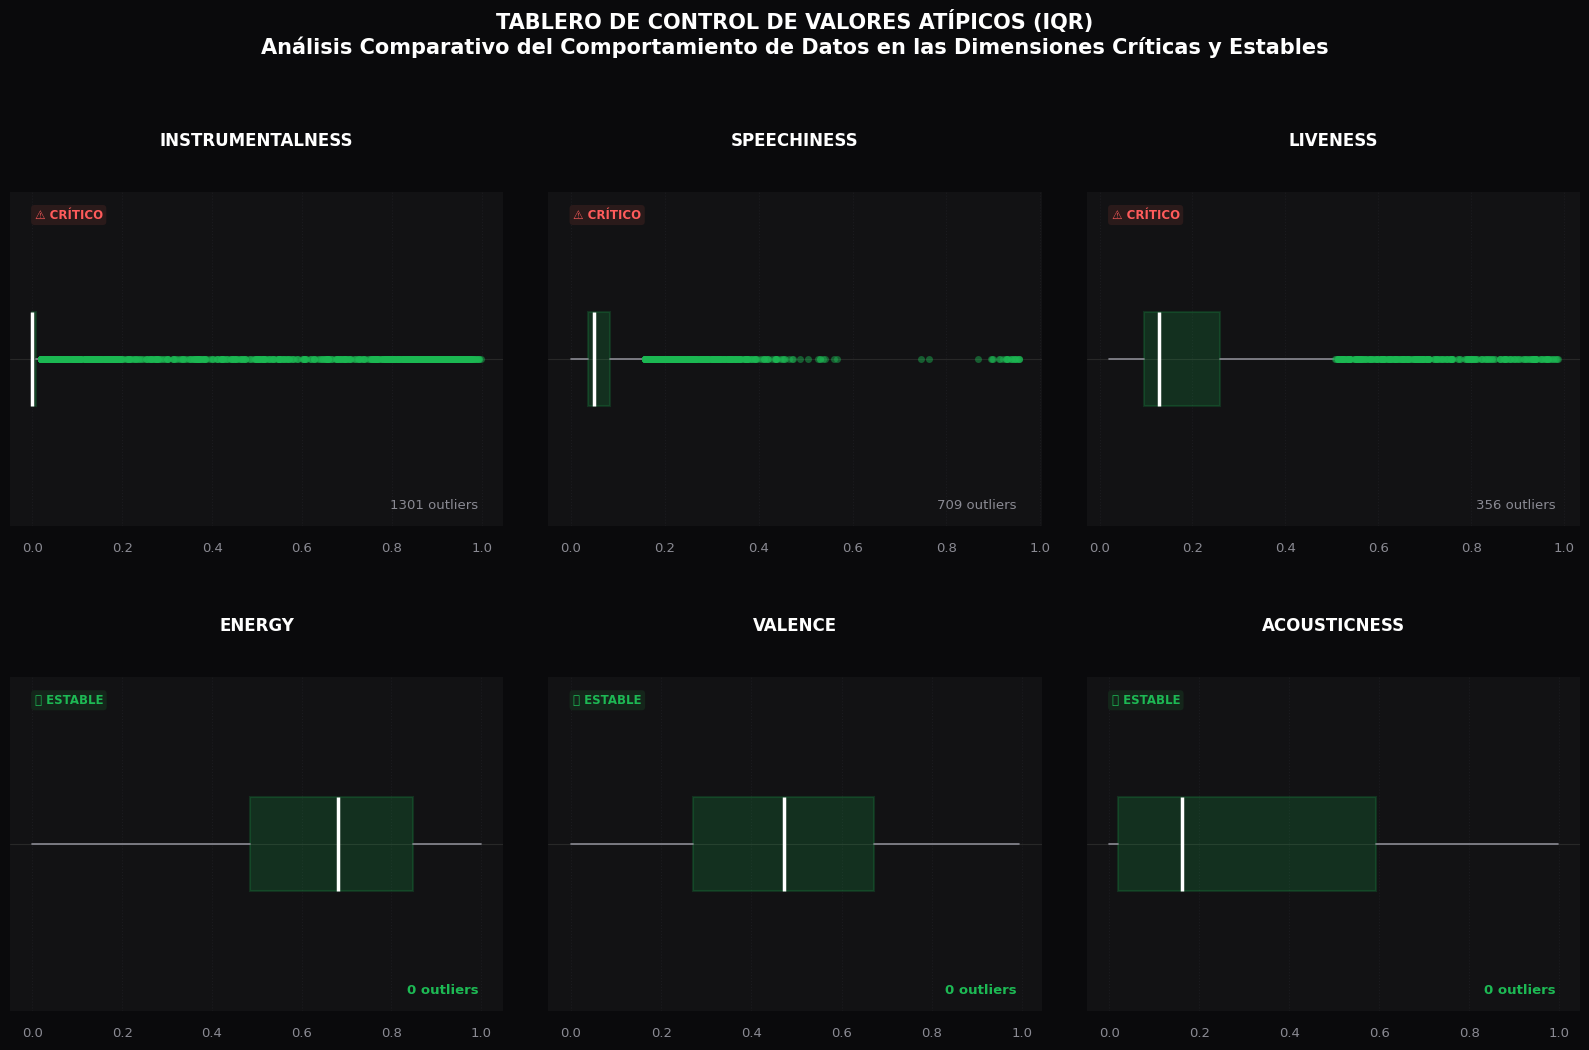

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# ==============================================================================
# 1. ANÁLISIS ESTADÍSTICO E IDENTIFICACIÓN DINÁMICA
# ==============================================================================
conteos_outliers = {}
columnas_analisis = list(data.columns)
for col in columnas_analisis:
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    
    # Contar outliers
    total_outliers = ((data[col] < limite_inferior) | (data[col] > limite_superior)).sum()
    conteos_outliers[col] = total_outliers
# Ordenar variables por outliers
serie_conteos = pd.Series(conteos_outliers).sort_values(ascending=False)
# Extraer grupos
top3_mas_outliers = list(serie_conteos.head(3).index)
variables_con_cero = serie_conteos[serie_conteos == 0]
if len(variables_con_cero) >= 3:
    top3_cero_outliers = list(variables_con_cero.head(3).index)
else:
    top3_cero_outliers = list(serie_conteos.tail(3).index)
# ==============================================================================
# 2. CONFIGURACIÓN ESTILÍSTICA PREMIUM (Spotify Dashboard Theme)
# ==============================================================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Poppins', 'Inter', 'Montserrat', 'DejaVu Sans', 'Arial']
# Paleta Cromática de Vanguardia (Dark Cyberpunk / Spotify High-Fi)
COLOR_BG = '#0A0A0C'             # Negro absoluto de fondo
COLOR_CARD = '#121214'           # Gris grafito para las tarjetas
COLOR_TEXT_MAIN = '#FFFFFF'      # Blanco puro
COLOR_TEXT_SEC = '#8A8A93'       # Gris frío para etiquetas secundarias
COLOR_GREEN = '#1DB954'          # Verde neón Spotify
COLOR_RED = '#FF5B5B'            # Rojo coral de advertencia
COLOR_GRID = '#1F1F24'           # Rejilla de alta opacidad
plt.rcParams['figure.facecolor'] = COLOR_BG
plt.rcParams['text.color'] = COLOR_TEXT_MAIN
# ==============================================================================
# 3. DIBUJAR TABLERO DE BOXPLOTS DE ALTA FIDELIDAD
# ==============================================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 11))
# Configuración ultra-limpia para cajas de cristal translúcido
boxprops = dict(facecolor=COLOR_GREEN, color=COLOR_GREEN, alpha=0.18, linewidth=1.5)
whiskerprops = dict(color=COLOR_TEXT_SEC, linestyle='-', linewidth=1.2)
medianprops = dict(color='#FFFFFF', linewidth=2.5) # Mediana en blanco puro brillante
flierprops = dict(
    marker='o', 
    markerfacecolor=COLOR_GREEN, 
    markeredgecolor='none', 
    markersize=5.0, 
    alpha=0.45,
    zorder=3
) # Outliers como esferas verdes de baja opacidad para simular brillo neón
# --- FILA 1: Top 3 Con Más Outliers (Estilo Alerta) ---
for j, col in enumerate(top3_mas_outliers):
    ax = axes[0, j]
    ax.set_facecolor(COLOR_CARD)
    
    # Boxplot minimalista (showcaps=False elimina los molestos tapones de los lados)
    ax.boxplot(
        data[col],
        vert=False,
        patch_artist=True,
        showcaps=False,
        boxprops=boxprops,
        whiskerprops=whiskerprops,
        medianprops=medianprops,
        flierprops=flierprops,
        widths=0.28
    )
    
    # Títulos estilizados con píldora de advertencia
    total_out = conteos_outliers[col]
    titulo_texto = f"{col.upper()}\n"
    ax.text(0.05, 0.92, "⚠️ CRÍTICO", color=COLOR_RED, fontsize=8.5, fontweight='bold', 
            transform=ax.transAxes, bbox=dict(facecolor='#2A1A1A', edgecolor='none', boxstyle='round,pad=0.3'))
    
    ax.set_title(titulo_texto, fontsize=12, fontweight='bold', pad=18, color=COLOR_TEXT_MAIN)
    ax.text(0.95, 0.05, f"{total_out} outliers", color=COLOR_TEXT_SEC, fontsize=9.5, 
            ha='right', transform=ax.transAxes)
    
    # Limpieza absoluta de ejes
    ax.set_yticklabels([])
    ax.tick_params(axis='x', labelsize=9.5, colors=COLOR_TEXT_SEC, pad=8)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(True, axis='x', color=COLOR_GRID, linestyle=':', alpha=0.7)
# --- FILA 2: 3 Variables Limpias (Estilo Estable) ---
for j, col in enumerate(top3_cero_outliers):
    ax = axes[1, j]
    ax.set_facecolor(COLOR_CARD)
    
    # Boxplot minimalista sin outliers
    ax.boxplot(
        data[col],
        vert=False,
        patch_artist=True,
        showcaps=False,
        boxprops=boxprops,
        whiskerprops=whiskerprops,
        medianprops=medianprops,
        flierprops=flierprops,
        widths=0.28
    )
    
    # Títulos estilizados con píldora de estabilidad
    total_out = conteos_outliers[col]
    titulo_texto = f"{col.upper()}\n"
    ax.text(0.05, 0.92, "✅ ESTABLE", color=COLOR_GREEN, fontsize=8.5, fontweight='bold', 
            transform=ax.transAxes, bbox=dict(facecolor='#14251A', edgecolor='none', boxstyle='round,pad=0.3'))
    
    ax.set_title(titulo_texto, fontsize=12, fontweight='bold', pad=18, color=COLOR_TEXT_MAIN)
    ax.text(0.95, 0.05, "0 outliers", color=COLOR_GREEN, fontsize=9.5, fontweight='bold',
            ha='right', transform=ax.transAxes)
    
    # Limpieza absoluta de ejes
    ax.set_yticklabels([])
    ax.tick_params(axis='x', labelsize=9.5, colors=COLOR_TEXT_SEC, pad=8)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(True, axis='x', color=COLOR_GRID, linestyle=':', alpha=0.7)
# Título Principal del Dashboard Integrado (Corregido sin letterspacing)
plt.suptitle(
    "TABLERO DE CONTROL DE VALORES ATÍPICOS (IQR)\n"
    "Análisis Comparativo del Comportamiento de Datos en las Dimensiones Críticas y Estables",
    fontsize=15, 
    fontweight='bold', 
    y=0.97, 
    color=COLOR_TEXT_MAIN
)
# Ajuste fino de espaciado y márgenes libres
plt.tight_layout(rect=[0, 0.02, 1, 0.93], h_pad=4.5, w_pad=2.5)
plt.show()

### Ouliers Multivariados 

     📊 REPORTE DE OUTLIERS MULTIVARIADOS (DISTANCIA DE MAHALANOBIS) 
 • Dimensión del espacio analizado: 9 variables.
 • Distribución de referencia: Chi-Cuadrado con 9 gl.
 • Nivel de confianza seleccionado: 99.90% (alfa = 0.001).
 • Umbral Crítico Teórico (χ²): 27.8772
--------------------------------------------------------------------------------
 ✅ Registros típicos/estables: 5,623 canciones (98.65%)
 ⚠️ Outliers multivariados detectados: 77 canciones (1.35%)


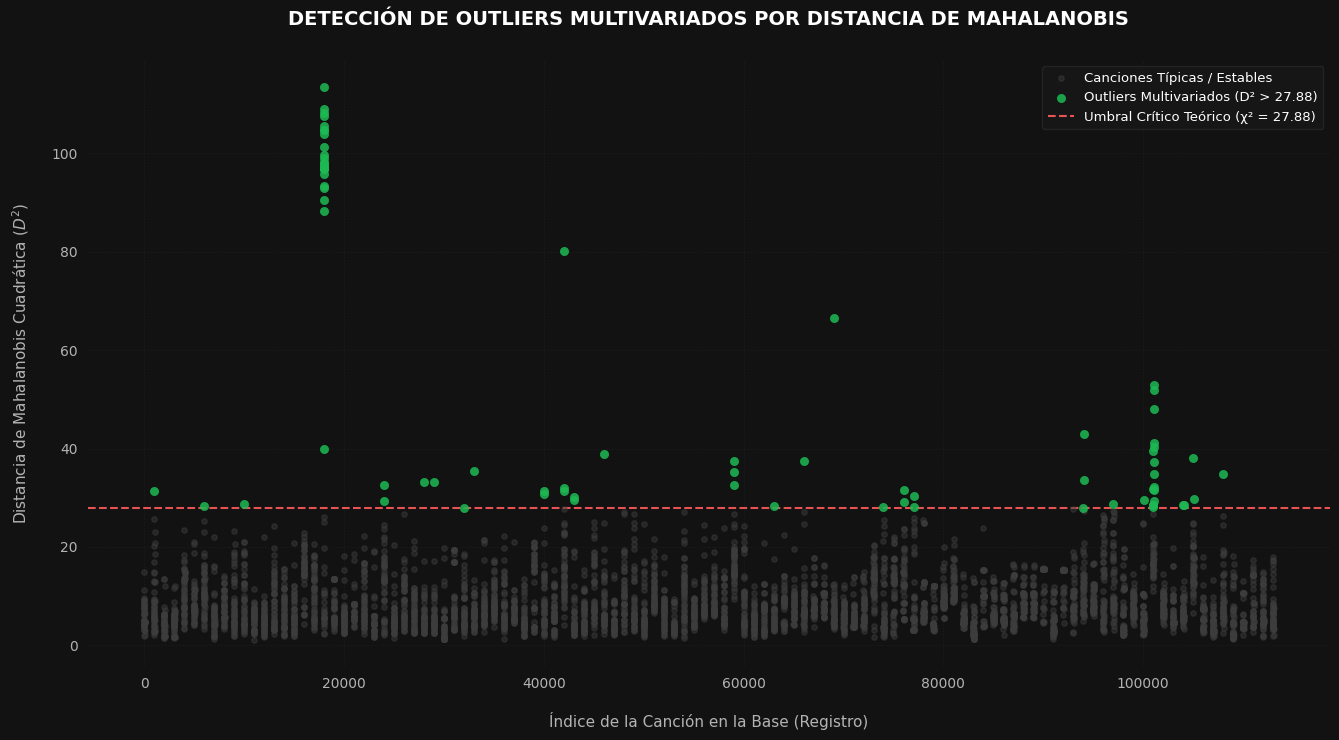

In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2
# ==============================================================================
# 1. CÁLCULO CIENTÍFICO DE LA DISTANCIA DE MAHALANOBIS (D²)
# ==============================================================================
# Extraemos los valores como una matriz NumPy para máxima velocidad
X = data.values
medias = np.mean(X, axis=0)
matriz_cov = np.cov(X.T)
# Inversa de la matriz de covarianza (robusta ya que el VIF es bajo)
matriz_cov_inv = np.linalg.inv(matriz_cov)
# Diferencia de cada registro con respecto al centroide de medias
diferencias = X - medias
# Distancia de Mahalanobis al cuadrado para cada fila
distancias_mahalanobis = np.sum(diferencias @ matriz_cov_inv * diferencias, axis=1)
# Añadir resultados a un DataFrame de control
df_analisis = data.copy()
df_analisis['Mahalanobis_D2'] = distancias_mahalanobis
# ==============================================================================
# 2. DETERMINACIÓN DEL UMBRAL CRÍTICO (CHI-CUADRADO)
# ==============================================================================
alpha = 0.001  # Nivel de significancia riguroso para bases grandes
grados_libertad = X.shape[1] # p = 9 variables
umbral_teorico = chi2.ppf(1 - alpha, df=grados_libertad)
# Clasificación
outliers = df_analisis[df_analisis['Mahalanobis_D2'] > umbral_teorico]
normales = df_analisis[df_analisis['Mahalanobis_D2'] <= umbral_teorico]
num_outliers = len(outliers)
porcentaje_outliers = (num_outliers / len(data)) * 100
# Reporte formal impreso
print("=" * 80)
print("     📊 REPORTE DE OUTLIERS MULTIVARIADOS (DISTANCIA DE MAHALANOBIS) ")
print("=" * 80)
print(f" • Dimensión del espacio analizado: {grados_libertad} variables.")
print(f" • Distribución de referencia: Chi-Cuadrado con {grados_libertad} gl.")
print(f" • Nivel de confianza seleccionado: {(1-alpha)*100:.2f}% (alfa = {alpha}).")
print(f" • Umbral Crítico Teórico (χ²): {umbral_teorico:.4f}")
print("-" * 80)
print(f" ✅ Registros típicos/estables: {len(normales):,} canciones ({100 - porcentaje_outliers:.2f}%)")
print(f" ⚠️ Outliers multivariados detectados: {num_outliers} canciones ({porcentaje_outliers:.2f}%)")
print("=" * 80)
# ==============================================================================
# 3. CONFIGURACIÓN ESTILÍSTICA (Tema Spotify Dark Premium)
# ==============================================================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Poppins', 'Inter', 'Montserrat', 'DejaVu Sans', 'Arial']
COLOR_BG = '#121212'           # Negro base Spotify
COLOR_CARD = '#181818'         # Gris tarjeta elevado
COLOR_TEXT_MAIN = '#FFFFFF'     # Blanco puro
COLOR_TEXT_SEC = '#B3B3B3'      # Gris claro Spotify
COLOR_GREEN = '#1DB954'         # Verde Spotify (Destacado exclusivo)
COLOR_RED = '#FF5B5B'            # Rojo de control / peligro
COLOR_GRID = '#242424'          # Rejilla sutil
# Configuración global
plt.rcParams['figure.facecolor'] = COLOR_BG
plt.rcParams['axes.facecolor'] = COLOR_BG
plt.rcParams['text.color'] = COLOR_TEXT_MAIN
plt.rcParams['axes.labelcolor'] = COLOR_TEXT_SEC
plt.rcParams['xtick.color'] = COLOR_TEXT_SEC
plt.rcParams['ytick.color'] = COLOR_TEXT_SEC
# ==============================================================================
# 4. GRÁFICO DE DISPERSIÓN DE MAHALANOBIS
# ==============================================================================
plt.figure(figsize=(13.5, 7.5))
ax = plt.gca()
# 1. Graficar puntos normales (en gris Spotify sutil)
plt.scatter(
    normales.index, 
    normales['Mahalanobis_D2'], 
    color='#3E3E3E', 
    alpha=0.45, 
    s=15, 
    label='Canciones Típicas / Estables',
    zorder=2
)
# 2. Graficar outliers (resaltados en Verde Spotify brillante)
plt.scatter(
    outliers.index, 
    outliers['Mahalanobis_D2'], 
    color=COLOR_GREEN, 
    alpha=0.85, 
    s=35, 
    edgecolors=COLOR_GREEN,
    linewidths=0.5,
    label=f'Outliers Multivariados (D² > {umbral_teorico:.2f})',
    zorder=3
)
# 3. Dibujar línea de control del umbral crítico
plt.axhline(
    y=umbral_teorico, 
    color=COLOR_RED, 
    linestyle='--', 
    linewidth=1.5, 
    alpha=0.9, 
    label=f'Umbral Crítico Teórico (χ² = {umbral_teorico:.2f})',
    zorder=1
)
# Estilo minimalista puro
for spine in ax.spines.values():
    spine.set_visible(False)
# Rejilla punteada horizontal y vertical muy sutil
ax.grid(True, axis='both', color=COLOR_GRID, linestyle=':', alpha=0.6, zorder=0)
# Títulos y etiquetas en Poppins
plt.title("DETECCIÓN DE OUTLIERS MULTIVARIADOS POR DISTANCIA DE MAHALANOBIS", 
          fontsize=14, fontweight='bold', pad=25, color=COLOR_TEXT_MAIN)
plt.xlabel("Índice de la Canción en la Base (Registro)", fontsize=11, labelpad=15, color=COLOR_TEXT_SEC)
plt.ylabel("Distancia de Mahalanobis Cuadrática ($D^2$)", fontsize=11, labelpad=15, color=COLOR_TEXT_SEC)
# Leyenda premium integrada
plt.legend(
    facecolor=COLOR_CARD, 
    edgecolor='#282828', 
    loc='upper right', 
    fontsize=9.5, 
    labelcolor=COLOR_TEXT_MAIN
)
plt.tight_layout()
plt.show()

## Otro